# Kibergrad

V datotek `Kibergrad.csv` se nahajajo informacije o 43.886 družinah, ki stanujejo v mestu Kibergrad. Za vsako družino so zabeleženi naslednji podatki (ne boste potrebovali vseh):

- Tip družine (od 1 do 3)
- Število članov družine
- Število otrok v družini
- Skupni dohodek družine
- Mestna četrt, v kateri stanuje družina (od 1 do 4)
- Stopnja izobrazbe vodje gospodinjstva (od 31 do 46)

In [25]:
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

kibergrad = pd.read_csv("../data/Kibergrad.csv")

Vzemite enostavni slučajni vzorec 200 družin in na njegovi podlagi ocenite povprečno število otrok na družino v Kibergradu.

In [26]:
sample = kibergrad.sample(n=200)
sample_mean = sample.OTROK.mean()

Ocenite standardno napako in postavite 95% interval zaupanja.

In [27]:
sample_se = sample.OTROK.sem()

alpha = 1 - 0.95
quantile = norm.ppf(1 - alpha / 2)

sample_delta = quantile * sample_se

sample_ci = (sample_mean - sample_delta, sample_mean + sample_delta)

Vzorčno povprečje in ocenjeno standardno napako primerjajte s populacijskim povprečjem in pravo standardno napako. Ali interval zaupanja iz prejšnje točke pokrije populacijsko povprečje?

In [5]:
true_mean = kibergrad.OTROK.mean()
true_se = kibergrad.OTROK.sem()

Vzemite še 99 enostavnih slučajnih vzorcev in prav tako za vsakega določite 95% interval zaupanja. Narišite intervale zaupanja, ki pripadajo tem 100 vzorcem. Koliko jih pokrije populacijsko povprečje?

In [6]:
samples200 = [sample]

for k in range(99):
    new_sample = kibergrad.sample(n=200)
    samples200.append(new_sample)

In [11]:
intervals200 = []
no_coverage200 = 0

for sample in samples200:
    mean = sample.OTROK.mean()
    se = sample.OTROK.sem()
    delta = quantile * se
    ci = (mean - delta, mean + delta)
    intervals200.append(ci)

    if true_mean < ci[0] or true_mean > ci[1]:
        no_coverage200 += 1

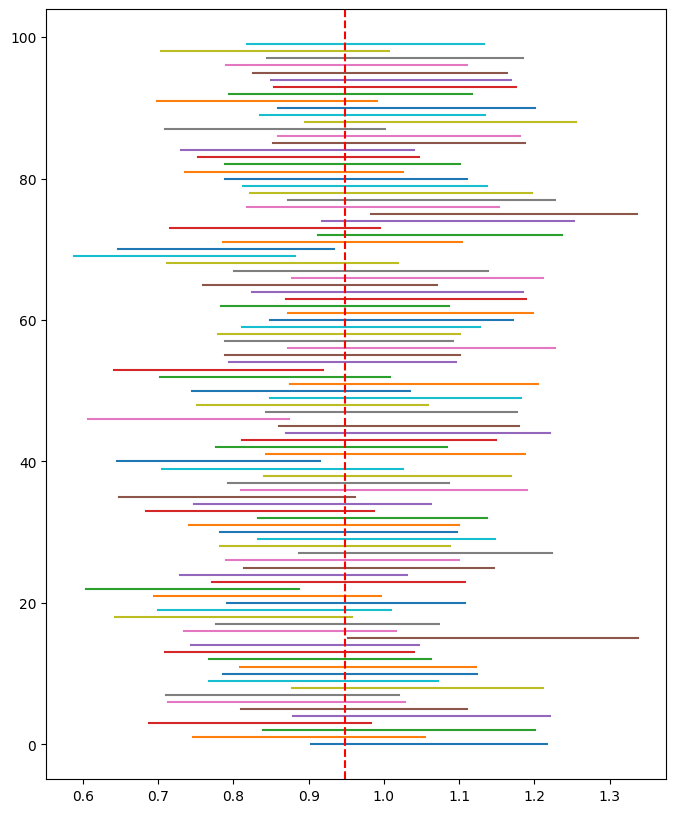

In [15]:
plt.figure(figsize=(8, 10))

for i, (low, high) in enumerate(intervals200):
    plt.plot([low, high], [i, i])

plt.axvline(true_mean, color="red", linestyle="--")

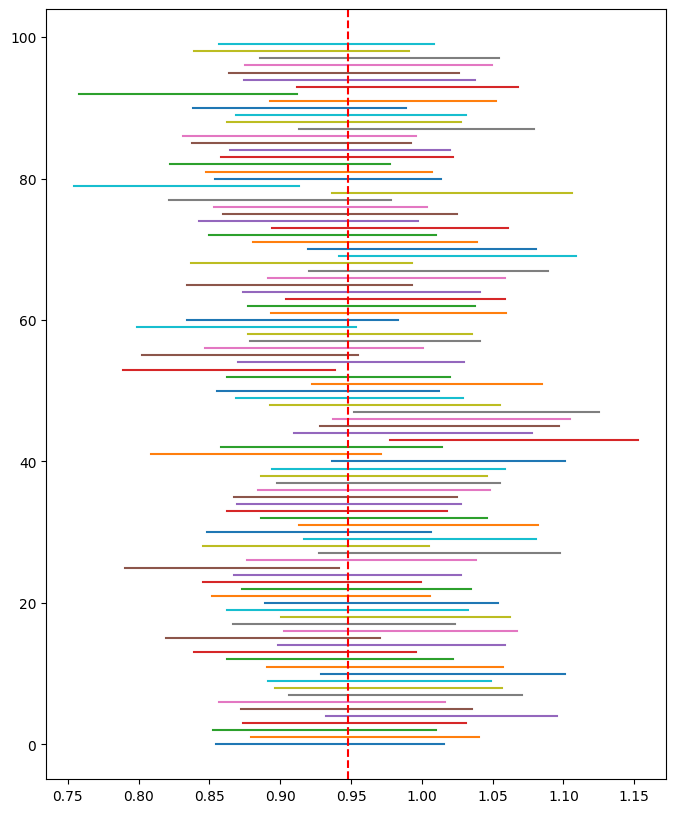

In [16]:
samples800 = []

for k in range(100):
    new_sample = kibergrad.sample(n=800)
    samples800.append(new_sample)

intervals800 = []
no_coverage800 = 0

for sample in samples800:
    mean = sample.OTROK.mean()
    se = sample.OTROK.sem()
    delta = quantile * se
    ci = (mean - delta, mean + delta)
    intervals800.append(ci)

    if true_mean < ci[0] or true_mean > ci[1]:
        no_coverage800 += 1

plt.figure(figsize=(8, 10))

for i, (low, high) in enumerate(intervals800):
    plt.plot([low, high], [i, i])

plt.axvline(true_mean, color="red", linestyle="--")

In [19]:
print("vzorčno povprečje:", sample_mean)
print("vzorčna napaka:", sample_se)
print("vzorčni IZ:", sample_ci)
print("pravo povprečje:", true_mean)
print("prava standardna napaka:", true_se)
print("st IZ dolzine 200, ki ne pokrije", no_coverage200)
print("st IZ dolzine 800, ki ne pokrije", no_coverage800)

vzorčno povprečje: 1.06
vzorčna napaka: 0.038801567488304343
vzorčni IZ: (np.float64(0.9839503251792232), np.float64(1.136049674820777))
pravo povprečje: 0.9479332816843641
prava standardna napaka: 0.0055239470446406015
st IZ dolzine 200, ki ne pokrije 8
st IZ dolzine 800, ki ne pokrije 6
